# Positional Information Ablation

This experiment reuses the Tiny Transformer classifier and changes one component: learned positional embeddings. The aim is to turn the earlier implementation into a small controlled comparison.

## What I wanted to understand

The complete Tiny Transformer can learn whether `A` appears before `B`. Does it still learn that rule when token positions are not supplied?

The sequences have the same token counts in both classes, so token identity alone should not determine the label.

In [1]:
%matplotlib inline

from itertools import combinations, product
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, SVG, display
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from model import TinyTransformerClassifier

torch.use_deterministic_algorithms(True)
plt.rcParams['figure.dpi'] = 120
figures_dir = Path('figures')
figures_dir.mkdir(exist_ok=True)

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.13.0


## Dataset

Each sequence begins with `[CLS]`, then contains exactly one `A`, one `B`, and four filler tokens. Label `1` means `A` is before `B`; label `0` means `B` is before `A`.

The dataset is generated once with seed `7`. Examples are selected without replacement and then split into 800 training and 200 validation sequences, so every run sees the same disjoint examples.

In [2]:
DATASET_SEED = 7
vocabulary = ['[CLS]', 'A', 'B', 'X', 'Y', 'Z']
token_to_id = {token: index for index, token in enumerate(vocabulary)}
id_to_token = {index: token for token, index in token_to_id.items()}
content_length = 6
seq_len = content_length + 1

def make_dataset(num_examples, seed):
    if num_examples % 2 != 0:
        raise ValueError('num_examples must be even to keep the labels balanced')

    generator = torch.Generator().manual_seed(seed)
    filler_ids = range(token_to_id['X'], len(vocabulary))
    sequences_by_label = {0: [], 1: []}

    for label in sequences_by_label:
        first_token, second_token = (token_to_id['A'], token_to_id['B']) if label == 1 else (token_to_id['B'], token_to_id['A'])
        for first_position, second_position in combinations(range(content_length), 2):
            filler_positions = [position for position in range(content_length) if position not in (first_position, second_position)]
            for fillers in product(filler_ids, repeat=len(filler_positions)):
                content = [None] * content_length
                content[first_position] = first_token
                content[second_position] = second_token
                for position, filler in zip(filler_positions, fillers):
                    content[position] = filler
                sequences_by_label[label].append([token_to_id['[CLS]']] + content)

    examples_per_label = num_examples // 2
    token_ids, labels = [], []
    for label, sequences in sequences_by_label.items():
        selected = torch.randperm(len(sequences), generator=generator)[:examples_per_label].tolist()
        token_ids.extend(sequences[index] for index in selected)
        labels.extend([label] * examples_per_label)

    shuffle_order = torch.randperm(num_examples, generator=generator)
    return torch.tensor(token_ids)[shuffle_order], torch.tensor(labels)[shuffle_order]

all_token_ids, all_labels = make_dataset(num_examples=1000, seed=DATASET_SEED)
train_token_ids, validation_token_ids = all_token_ids[:800], all_token_ids[800:]
train_labels, validation_labels = all_labels[:800], all_labels[800:]

assert len(set(map(tuple, all_token_ids.tolist()))) == 1000
assert torch.bincount(all_labels).tolist() == [500, 500]
assert set(map(tuple, train_token_ids.tolist())).isdisjoint(map(tuple, validation_token_ids.tolist()))
print('Unique sequences: 1000')
print('Class counts:', torch.bincount(all_labels).tolist())
print('Train / validation split: 800 / 200')
print('Train and validation sequences are disjoint: True')

Unique sequences: 1000
Class counts: [500, 500]
Train / validation split: 800 / 200
Train and validation sequences are disjoint: True


## With vs without positional embeddings

The left flow adds a learned vector for each token position. The right flow sends token embeddings directly to the same encoder block. No other model component changes.

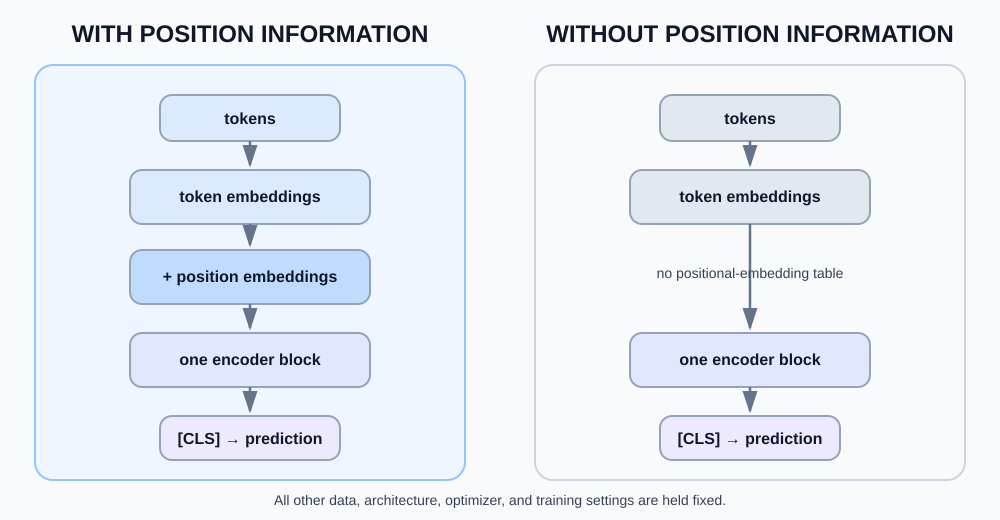

In [3]:
display(SVG(filename=str(figures_dir / 'architecture-flow.svg')))

In [4]:
d_model = 32
num_heads = 4
d_ff = 64
num_classes = 2

with_positions = TinyTransformerClassifier(len(vocabulary), seq_len, d_model, num_heads, d_ff, num_classes, use_positions=True)
without_positions = TinyTransformerClassifier(len(vocabulary), seq_len, d_model, num_heads, d_ff, num_classes, use_positions=False)

assert with_positions.position_embedding is not None
assert without_positions.position_embedding is None
assert with_positions(train_token_ids[:4]).shape == without_positions(train_token_ids[:4]).shape == (4, 2)
print('Both conditions produce logits shaped [batch, 2].')
print('The no-position model has no positional-embedding table.')

Both conditions produce logits shaped [batch, 2].
The no-position model has no positional-embedding table.


## Training setup

Both conditions use one encoder block, `d_model=32`, four attention heads, a `32 → 64 → 32` FFN, `[CLS]` classification, AdamW with learning rate `0.003` and weight decay `0.0001`, batch size `64`, and 30 epochs.

The fixed training seeds change model initialization and batch order, not the dataset split.

In [5]:
batch_size = 64
epochs = 30
learning_rate = 0.003
weight_decay = 0.0001
seeds = [7, 13, 23, 37, 53]

histories = {}
example_predictions = {}
example_indices = [0, 1, 2, 3]

def evaluate(model, loader, loss_function):
    model.eval()
    total_loss = total_correct = total_examples = 0
    with torch.no_grad():
        for token_ids, labels in loader:
            logits = model(token_ids)
            total_loss += loss_function(logits, labels).item() * len(labels)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += len(labels)
    return total_loss / total_examples, total_correct / total_examples

def train_and_evaluate(seed, use_positions):
    torch.manual_seed(seed)
    model = TinyTransformerClassifier(
        vocab_size=len(vocabulary), seq_len=seq_len, d_model=d_model, num_heads=num_heads,
        d_ff=d_ff, num_classes=num_classes, use_positions=use_positions,
    )
    train_loader = DataLoader(
        TensorDataset(train_token_ids, train_labels), batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    validation_loader = DataLoader(TensorDataset(validation_token_ids, validation_labels), batch_size=batch_size)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    history = {'train_loss': [], 'validation_loss': [], 'train_accuracy': [], 'validation_accuracy': []}

    for _ in range(epochs):
        model.train()
        for token_ids, labels in train_loader:
            loss = loss_function(model(token_ids), labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss, train_accuracy = evaluate(model, train_loader, loss_function)
        validation_loss, validation_accuracy = evaluate(model, validation_loader, loss_function)
        history['train_loss'].append(train_loss)
        history['validation_loss'].append(validation_loss)
        history['train_accuracy'].append(train_accuracy)
        history['validation_accuracy'].append(validation_accuracy)

    condition = 'With positional information' if use_positions else 'Without positional information'
    histories[(seed, condition)] = history
    with torch.no_grad():
        probabilities = torch.softmax(model(validation_token_ids[example_indices]), dim=1)
    example_predictions[condition] = (probabilities.argmax(dim=1), probabilities)
    return {
        'seed': seed,
        'condition': condition,
        'train_loss': history['train_loss'][-1],
        'validation_loss': history['validation_loss'][-1],
        'train_accuracy': history['train_accuracy'][-1],
        'validation_accuracy': history['validation_accuracy'][-1],
    }

## Run five fixed seeds

Each pair of runs starts from the same seed. The nested loop makes the comparison explicit: only `use_positions` changes within a seed.

In [6]:
results = []

for seed in seeds:
    for use_positions in [True, False]:
        metrics = train_and_evaluate(
            seed=seed,
            use_positions=use_positions,
        )
        results.append(metrics)

print(f'Completed {len(results)} runs.')

Completed 10 runs.


## Collecting results

The DataFrame keeps the final metrics for every run in one place before aggregating them.

In [7]:
results_df = pd.DataFrame(results)
results_df

,seed,condition,train_loss,validation_loss,train_accuracy,validation_accuracy
0,7,With positional information,0.000159,0.000160,1.00000,1.000
1,7,Without positional information,0.693640,0.699972,0.51000,0.460
2,13,With positional information,0.000138,0.000136,1.00000,1.000
3,13,Without positional information,0.693058,0.697481,0.51000,0.460
4,23,With positional information,0.000184,0.000185,1.00000,1.000
5,23,Without positional information,0.693470,0.692305,0.49000,0.540
6,37,With positional information,0.000090,0.000089,1.00000,1.000
7,37,Without positional information,0.693352,0.692826,0.49125,0.545
8,53,With positional information,0.000184,0.000182,1.00000,1.000
9,53,Without positional information,0.692878,0.695878,0.51375,0.455


In [8]:
summary_df = (
    results_df.groupby('condition', sort=False)['validation_accuracy']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'mean validation accuracy', 'std': 'std'})
    .reset_index()
)
summary_df

,condition,mean validation accuracy,std
0,With positional information,1.000,0.000000
1,Without positional information,0.492,0.046179


## Comparing runs

The first plot keeps every seed visible as a paired comparison. The second summarizes training behavior with mean curves and ±1 standard-deviation bands; solid lines are training metrics and dashed lines are validation metrics.

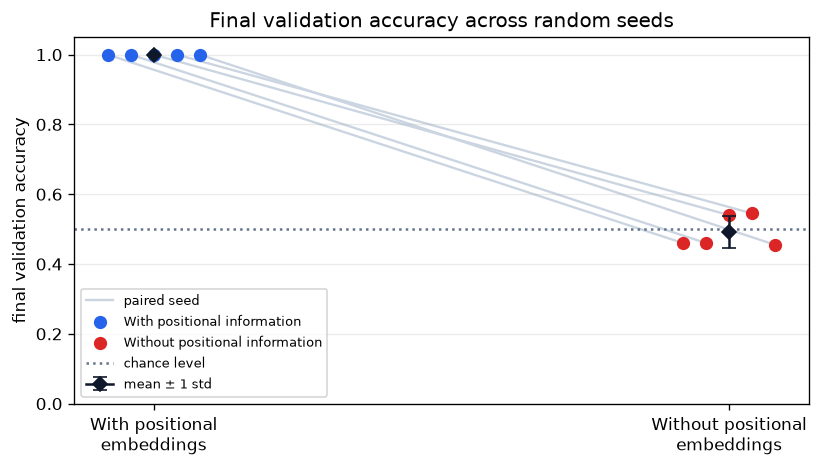

In [9]:
colors = {'With positional information': '#2563eb', 'Without positional information': '#dc2626'}
conditions = list(colors)
seed_offsets = dict(zip(seeds, [-0.08, -0.04, 0.0, 0.04, 0.08]))

fig, ax = plt.subplots(figsize=(7, 4))
for seed in seeds:
    paired = results_df[results_df['seed'] == seed].set_index('condition')['validation_accuracy']
    offset = seed_offsets[seed]
    ax.plot([offset, 1 + offset], [paired[conditions[0]], paired[conditions[1]]], color='#cbd5e1', linewidth=1.4, zorder=1, label='paired seed' if seed == seeds[0] else None)

for condition_index, condition in enumerate(conditions):
    group = results_df[results_df['condition'] == condition]
    x_values = [condition_index + seed_offsets[seed] for seed in group['seed']]
    ax.scatter(x_values, group['validation_accuracy'], color=colors[condition], s=48, zorder=3, label=condition)
    mean = group['validation_accuracy'].mean()
    std = group['validation_accuracy'].std()
    ax.errorbar(condition_index, mean, yerr=std, color='#0f172a', marker='D', markersize=6, capsize=4, linewidth=1.5, zorder=4, label='mean ± 1 std' if condition_index == 0 else None)

ax.axhline(0.5, color='#64748b', linestyle=':', label='chance level')
ax.set_xticks([0, 1], ['With positional\nembeddings', 'Without positional\nembeddings'])
ax.set_ylabel('final validation accuracy')
ax.set_ylim(0.0, 1.05)
ax.set_title('Final validation accuracy across random seeds')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='lower left', fontsize=8)
fig.tight_layout()
fig.savefig(figures_dir / 'validation-accuracy-by-seed.png', bbox_inches='tight')
plt.show()

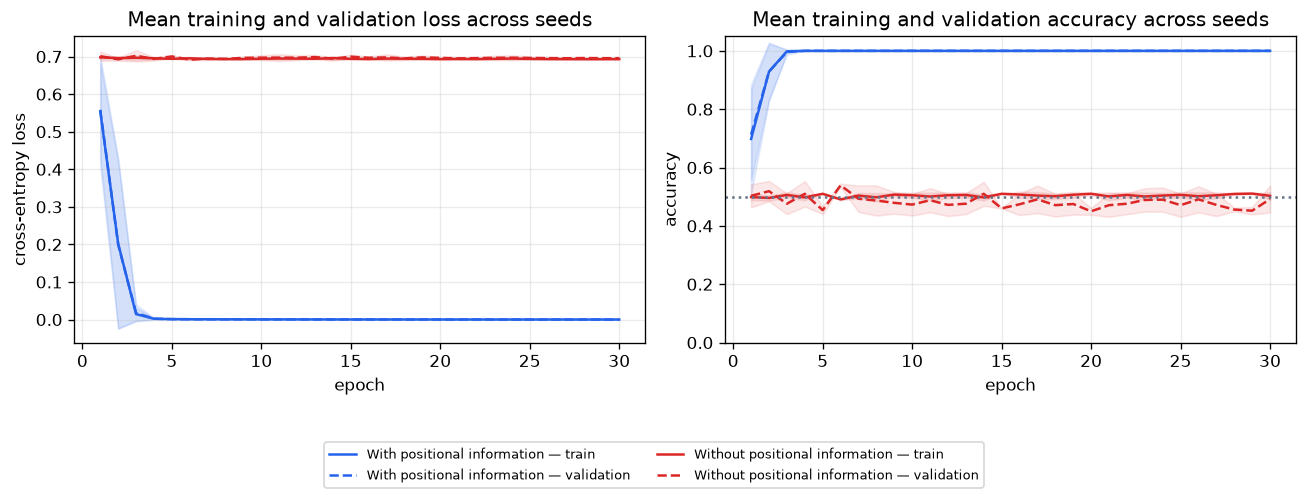

In [10]:
epochs_axis = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for condition in colors:
    condition_histories = [histories[(seed, condition)] for seed in seeds]
    for metric, axis, title, ylabel in [
        ('loss', axes[0], 'Mean training and validation loss across seeds', 'cross-entropy loss'),
        ('accuracy', axes[1], 'Mean training and validation accuracy across seeds', 'accuracy'),
    ]:
        train_values = torch.tensor([history[f'train_{metric}'] for history in condition_histories])
        validation_values = torch.tensor([history[f'validation_{metric}'] for history in condition_histories])
        train_mean, train_std = train_values.mean(dim=0), train_values.std(dim=0)
        validation_mean, validation_std = validation_values.mean(dim=0), validation_values.std(dim=0)
        axis.plot(epochs_axis, train_mean, color=colors[condition], label=f'{condition} — train')
        axis.fill_between(epochs_axis, train_mean - train_std, train_mean + train_std, color=colors[condition], alpha=0.10)
        axis.plot(epochs_axis, validation_mean, color=colors[condition], linestyle='--', label=f'{condition} — validation')
        axis.fill_between(epochs_axis, validation_mean - validation_std, validation_mean + validation_std, color=colors[condition], alpha=0.10)
        axis.set_title(title)
        axis.set_xlabel('epoch')
        axis.set_ylabel(ylabel)
        axis.grid(alpha=0.25)

axes[1].set_ylim(0.0, 1.05)
axes[1].axhline(0.5, color='#64748b', linestyle=':')
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=8, bbox_to_anchor=(0.5, -0.10))
fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.savefig(figures_dir / 'training-curves.png', bbox_inches='tight')
plt.show()

## Inspecting examples

These are held-out sequences. The displayed predictions come from the final seed (`53`) for each condition, so they are concrete examples rather than an aggregate claim.

In [11]:
table_lines = [
    '| tokens | true label | with positions | without positions |',
    '| --- | ---: | --- | --- |',
]
with_predictions, with_probabilities = example_predictions['With positional information']
without_predictions, without_probabilities = example_predictions['Without positional information']

for row, index in enumerate(example_indices):
    tokens = ' '.join(id_to_token[token_id] for token_id in validation_token_ids[index].tolist())
    with_label = with_predictions[row].item()
    without_label = without_predictions[row].item()
    with_confidence = with_probabilities[row, with_label].item()
    without_confidence = without_probabilities[row, without_label].item()
    table_lines.append(
        f'| `{tokens}` | {validation_labels[index].item()} | {with_label} ({with_confidence:.3f}) | {without_label} ({without_confidence:.3f}) |'
    )

display(Markdown('\n'.join(table_lines)))

| tokens | true label | with positions | without positions |
| --- | ---: | --- | --- |
| `[CLS] B A X Y X Z` | 0 | 0 (1.000) | 0 (0.508) |
| `[CLS] A Z Y Z B X` | 1 | 1 (1.000) | 0 (0.513) |
| `[CLS] A Z Z B Z Y` | 1 | 1 (1.000) | 0 (0.518) |
| `[CLS] X Z A Y Z B` | 1 | 1 (1.000) | 0 (0.513) |

## What I observed

Use the table and plots above as the record of this run. The comparison tests a narrow expectation: the positional condition can represent the order rule, while the no-position condition cannot use token order through this architecture.

## Limitations

This is a deliberately small synthetic task, not a language-understanding benchmark. It compares learned absolute positions with no positional information; it does not compare sinusoidal encodings, relative positions, RoPE, or long-context behavior.